# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

**Dataset:** Play Tennis Dataset (50 instances, 4 features)  

**Objective:** Build a complete classification pipeline using the Play Tennis dataset.

| Task | Description |
|------|-------------|
| 1 | Load & preprocess data (Label Encoding of categorical features) |
| 2 | 80:20 Train-Test Split |
| 3 | Train `CategoricalNB` and evaluate (Accuracy, CM, Report) |
| 4 | Single-sample inference for custom weather query |
| 5 | Compare with Decision Tree, Logistic Regression, SVM |

---

## Step 1: Import Required Libraries

We import all machine learning, data manipulation, and visualization libraries needed for this lab.
- `pandas` / `numpy` — data loading and numerical operations
- `sklearn` — preprocessing, model training, evaluation metrics
- `matplotlib` / `seaborn` — confusion matrix heatmaps and comparison charts
- `warnings` — suppress non-critical deprecation warnings for clean output

In [3]:
# ─────────────────────────────────────────────────────────────────
#  STEP 1: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Classifiers
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print('All libraries imported successfully!')
print('scikit-learn version:', __import__('sklearn').__version__)

All libraries imported successfully!
scikit-learn version: 1.9.0


---
## Step 2: Load and Explore the Dataset

The **Play Tennis** dataset contains **50 weather observations** used to decide whether to play tennis.

| Feature | Type | Possible Values |
|---------|------|----------------|
| Outlook | Categorical | Sunny, Overcast, Rain |
| Temperature | Categorical | Hot, Mild, Cool |
| Humidity | Categorical | High, Normal |
| Wind | Categorical | Weak, Strong |
| **Play Tennis** | Target | **Yes**, **No** |

The `No` column is just a row index — it carries zero predictive information and is dropped immediately.

In [4]:
# ─────────────────────────────────────────────────────────────────
#  STEP 2a: LOAD DATASET
# ─────────────────────────────────────────────────────────────────
df = pd.read_csv('Lab 8 - Sheet1.csv')

# Drop the row-number column 'No' — not a predictive feature
df.drop(columns=['No'], inplace=True)

print('Dataset Shape:', df.shape)
print('Column Names :', list(df.columns))
print()
print('First 10 rows of the dataset:')
df.head(10)

Dataset Shape: (50, 5)
Column Names : ['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis']

First 10 rows of the dataset:


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [5]:
# ─────────────────────────────────────────────────────────────────
#  STEP 2b: DATASET OVERVIEW
# ─────────────────────────────────────────────────────────────────
print('=' * 55)
print('DATASET INFORMATION')
print('=' * 55)
df.info()

print()
print('=' * 55)
print('UNIQUE VALUES PER FEATURE')
print('=' * 55)
for col in df.columns:
    vals = df[col].unique().tolist()
    print(f'  {col:20s} -> {vals}')

print()
print('=' * 55)
print('TARGET CLASS DISTRIBUTION')
print('=' * 55)
vc = df['Play Tennis'].value_counts()
print(vc)
print()
pct = df['Play Tennis'].value_counts(normalize=True).mul(100).round(1)
for cls, p in pct.items():
    print(f'  {cls}: {p}%')

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Outlook      50 non-null     str  
 1   Temperature  50 non-null     str  
 2   Humidity     50 non-null     str  
 3   Wind         50 non-null     str  
 4   Play Tennis  50 non-null     str  
dtypes: str(5)
memory usage: 2.1 KB

UNIQUE VALUES PER FEATURE
  Outlook              -> ['Sunny', 'Overcast', 'Rain']
  Temperature          -> ['Hot', 'Mild', 'Cool']
  Humidity             -> ['High', 'Normal']
  Wind                 -> ['Weak', 'Strong']
  Play Tennis          -> ['No', 'Yes']

TARGET CLASS DISTRIBUTION
Play Tennis
Yes    34
No     16
Name: count, dtype: int64

  Yes: 68.0%
  No: 32.0%


---
## Step 3: Data Preprocessing — Label Encoding

Machine learning models work with **numbers**, not strings. We use **`LabelEncoder`** from scikit-learn to convert each categorical column into integers.

### Why LabelEncoder for CategoricalNB?
> `CategoricalNB` requires non-negative integer inputs where each integer represents a distinct category class. `LabelEncoder` maps unique strings to integers sorted **alphabetically** — which is exactly the format CategoricalNB expects.

**Example encoding:**
- Outlook: Overcast=0, Rain=1, Sunny=2
- Humidity: High=0, Normal=1
- Wind: Strong=0, Weak=1
- Play Tennis: No=0, Yes=1

We store **one encoder per column** in a dictionary — this allows us to:
1. Decode numeric predictions back to 'Yes'/'No'
2. Correctly encode new single-sample queries at inference time

In [6]:
# ─────────────────────────────────────────────────────────────────
#  STEP 3: LABEL ENCODING
# ─────────────────────────────────────────────────────────────────
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col   = 'Play Tennis'

# One LabelEncoder per column (for decoding + new query encoding)
label_encoders = {}
df_encoded = df.copy()

print('Feature Encoding Mapping:')
print('-' * 50)
for col in feature_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:15s}: {mapping}')

# Encode the target column
le_target = LabelEncoder()
df_encoded[target_col] = le_target.fit_transform(df[target_col])
label_encoders[target_col] = le_target
tgt_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f'  {target_col:15s}: {tgt_mapping}  <- TARGET')

print()
print('Encoded Dataset (first 10 rows):')
df_encoded.head(10)

Feature Encoding Mapping:
--------------------------------------------------
  Outlook        : {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
  Temperature    : {'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
  Humidity       : {'High': np.int64(0), 'Normal': np.int64(1)}
  Wind           : {'Strong': np.int64(0), 'Weak': np.int64(1)}
  Play Tennis    : {'No': np.int64(0), 'Yes': np.int64(1)}  <- TARGET

Encoded Dataset (first 10 rows):


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


---
## Step 4: Dataset Partitioning — 80:20 Train-Test Split

We divide the 50-sample dataset into:
- **Training set (80% = 40 samples)** — used to fit all models
- **Testing set (20% = 10 samples)** — used to evaluate on unseen data

**Key parameters:**
- `random_state=42` — ensures the same split every run (reproducibility)
- `stratify=y` — ensures the Yes/No class ratio is preserved equally in both training and test sets, preventing a biased evaluation

In [7]:
# ─────────────────────────────────────────────────────────────────
#  STEP 4: TRAIN-TEST SPLIT (80:20)
# ─────────────────────────────────────────────────────────────────
X = df_encoded[feature_cols].values   # Feature matrix  (50 x 4)
y = df_encoded[target_col].values     # Target vector   (50,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Preserve class ratio in both splits
)

print('=' * 48)
print('  DATASET SPLIT SUMMARY')
print('=' * 48)
print(f'  Total samples    : {len(X)}')
n_train_pct = len(X_train) / len(X) * 100
n_test_pct  = len(X_test)  / len(X) * 100
print(f'  Training samples : {len(X_train)}  ({n_train_pct:.0f}%)')
print(f'  Testing  samples : {len(X_test)}   ({n_test_pct:.0f}%)')
print()
print('  Training class distribution:')
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
for u, c in zip(unique_tr, counts_tr):
    lbl = le_target.inverse_transform([u])[0]
    print(f'    Class {lbl:4s} -> {c} samples')
print()
print('  Testing class distribution:')
unique_te, counts_te = np.unique(y_test, return_counts=True)
for u, c in zip(unique_te, counts_te):
    lbl = le_target.inverse_transform([u])[0]
    print(f'    Class {lbl:4s} -> {c} samples')
print('=' * 48)

  DATASET SPLIT SUMMARY
  Total samples    : 50
  Training samples : 40  (80%)
  Testing  samples : 10   (20%)

  Training class distribution:
    Class No   -> 13 samples
    Class Yes  -> 27 samples

  Testing class distribution:
    Class No   -> 3 samples
    Class Yes  -> 7 samples


---
## Step 5: Categorical Naive Bayes — Model Training

### How Categorical Naive Bayes Works

Naive Bayes is a **probabilistic classifier** rooted in **Bayes' Theorem**:

$$P(Y \mid X_1, X_2, \ldots, X_n) \propto P(Y) \cdot \prod_{i=1}^{n} P(X_i \mid Y)$$

| Term | Meaning |
|------|----------|
| P(Y) | **Prior** — frequency of each class in training data |
| P(Xᵢ \| Y) | **Likelihood** — how often feature value Xᵢ appears with class Y |
| Naive assumption | All features are **conditionally independent** given the class |

### Why `CategoricalNB` instead of `GaussianNB`?
> `GaussianNB` assumes each feature follows a **Gaussian (normal) distribution** — appropriate for continuous data.  
> `CategoricalNB` is designed specifically for **discrete/categorical** features, modelling each feature as a categorical distribution — which is exactly what Outlook, Temperature, Humidity, Wind are.

### Laplace Smoothing (`alpha=1.0`)
> Adds a pseudo-count of 1 to every category-class pair. Without this, if a feature value (e.g., Temperature=Cool) was never seen with a class in training, its probability would be **zero**, which would collapse the entire product to zero regardless of other features.

In [8]:
# ─────────────────────────────────────────────────────────────────
#  STEP 5: CATEGORICAL NAIVE BAYES — TRAINING
# ─────────────────────────────────────────────────────────────────
cnb_model = CategoricalNB(alpha=1.0)   # alpha=1.0 -> Laplace smoothing
cnb_model.fit(X_train, y_train)

print('Categorical Naive Bayes model trained successfully!')
print(f'Number of training samples : {X_train.shape[0]}')
print(f'Number of features         : {X_train.shape[1]}')

cls_names = le_target.inverse_transform(cnb_model.classes_).tolist()
print(f'Classes learned            : {cls_names}')

prior_probs = np.exp(cnb_model.class_log_prior_)
print()
print('Class Prior Probabilities (from training data):')
for cls, p in zip(cls_names, prior_probs):
    bar = '#' * int(p * 30)
    print(f'  P({cls:3s}) = {p:.4f}  ({p*100:.2f}%)  |{bar}')

Categorical Naive Bayes model trained successfully!
Number of training samples : 40
Number of features         : 4
Classes learned            : ['No', 'Yes']

Class Prior Probabilities (from training data):
  P(No ) = 0.3250  (32.50%)  |#########
  P(Yes) = 0.6750  (67.50%)  |####################


---
## Step 6: Model Evaluation — Accuracy, Confusion Matrix, Classification Report

We evaluate the trained CategoricalNB model on the **test set** (10 unseen samples):

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall fraction of correct predictions |
| **Precision** | TP/(TP+FP) | Of predicted Positive, how many are truly Positive? |
| **Recall** | TP/(TP+FN) | Of actual Positives, how many did the model find? |
| **F1-Score** | 2×(P×R)/(P+R) | Harmonic mean of Precision and Recall |

The **Confusion Matrix** shows the full breakdown of correct and incorrect predictions per class.

In [9]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6a: PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────
y_pred_cnb = cnb_model.predict(X_test)

# Decode numeric labels back to 'Yes'/'No' for readable output
y_test_labels = le_target.inverse_transform(y_test)
y_pred_labels = le_target.inverse_transform(y_pred_cnb)

print('Actual vs Predicted — Test Set:')
print('-' * 44)
print(f'  {"Sample":>6}  {"Actual":>10}  {"Predicted":>10}  {"Result":>8}')
print('-' * 44)
for i, (act, pred) in enumerate(zip(y_test_labels, y_pred_labels), 1):
    result = 'Correct' if act == pred else 'WRONG'
    print(f'  {i:>6}  {act:>10}  {pred:>10}  {result:>8}')

Actual vs Predicted — Test Set:
--------------------------------------------
  Sample      Actual   Predicted    Result
--------------------------------------------
       1          No         Yes     WRONG
       2         Yes         Yes   Correct
       3          No          No   Correct
       4         Yes         Yes   Correct
       5         Yes         Yes   Correct
       6         Yes         Yes   Correct
       7         Yes         Yes   Correct
       8         Yes         Yes   Correct
       9          No          No   Correct
      10         Yes         Yes   Correct


In [10]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6b: ACCURACY SCORE
# ─────────────────────────────────────────────────────────────────
accuracy_cnb = accuracy_score(y_test, y_pred_cnb)
n_correct    = int(accuracy_cnb * len(y_test))

print('=' * 54)
print('  CATEGORICAL NAIVE BAYES -- EVALUATION METRICS')
print('=' * 54)
print(f'  Overall Model Accuracy : {accuracy_cnb * 100:.2f}%')
print(f'  Correct Predictions    : {n_correct} / {len(y_test)}')
print(f'  Incorrect Predictions  : {len(y_test) - n_correct} / {len(y_test)}')
print('=' * 54)

  CATEGORICAL NAIVE BAYES -- EVALUATION METRICS
  Overall Model Accuracy : 90.00%
  Correct Predictions    : 9 / 10
  Incorrect Predictions  : 1 / 10


Confusion Matrix (tabular):
            Predicted No  Predicted Yes
Actual No              2              1
Actual Yes             0              7


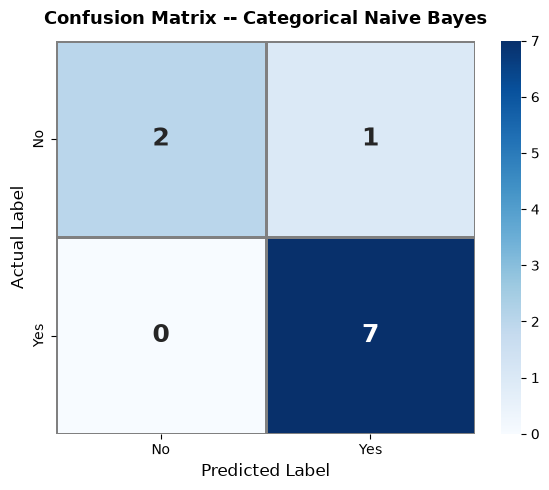


Confusion Matrix Interpretation:
  TN = 2  -> Correctly predicted "No"  (True Negative)
  FP = 1  -> Predicted "Yes", actually "No"  (False Positive)
  FN = 0  -> Predicted "No",  actually "Yes" (False Negative)
  TP = 7  -> Correctly predicted "Yes" (True Positive)


In [11]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6c: CONFUSION MATRIX — Heatmap
# ─────────────────────────────────────────────────────────────────
cm_cnb      = confusion_matrix(y_test, y_pred_cnb)
class_names = le_target.classes_   # ['No', 'Yes']

# Textual table
print('Confusion Matrix (tabular):')
cm_df = pd.DataFrame(cm_cnb,
                     index=[f'Actual {c}' for c in class_names],
                     columns=[f'Predicted {c}' for c in class_names])
print(cm_df)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='gray', ax=ax,
            annot_kws={'size': 18, 'weight': 'bold'})

ax.set_title('Confusion Matrix -- Categorical Naive Bayes',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_cnb.ravel()
print()
print('Confusion Matrix Interpretation:')
print(f'  TN = {tn}  -> Correctly predicted "No"  (True Negative)')
print(f'  FP = {fp}  -> Predicted "Yes", actually "No"  (False Positive)')
print(f'  FN = {fn}  -> Predicted "No",  actually "Yes" (False Negative)')
print(f'  TP = {tp}  -> Correctly predicted "Yes" (True Positive)')

In [12]:
# ─────────────────────────────────────────────────────────────────
#  STEP 6d: CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────
print('=' * 62)
print('  CLASSIFICATION REPORT -- Categorical Naive Bayes')
print('=' * 62)
report = classification_report(y_test_labels, y_pred_labels, target_names=class_names)
print(report)

print('Metric Definitions:')
print('  Precision = TP / (TP + FP)')
print('              Of all predicted Positive labels, how many were actually Positive?')
print()
print('  Recall    = TP / (TP + FN)')
print('              Of all actual Positive samples, how many did the model correctly identify?')
print()
print('  F1-Score  = 2 x (Precision x Recall) / (Precision + Recall)')
print('              Harmonic mean — balances Precision and Recall into one metric')
print()
print('  Support   = Actual number of samples per class in the test set')

  CLASSIFICATION REPORT -- Categorical Naive Bayes
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10

Metric Definitions:
  Precision = TP / (TP + FP)
              Of all predicted Positive labels, how many were actually Positive?

  Recall    = TP / (TP + FN)
              Of all actual Positive samples, how many did the model correctly identify?

  F1-Score  = 2 x (Precision x Recall) / (Precision + Recall)
              Harmonic mean — balances Precision and Recall into one metric

  Support   = Actual number of samples per class in the test set


---
## Step 7: Single-Sample Inference — Custom Weather Query

We test the trained Naive Bayes model on the following custom weather condition:

| Feature | Query Value |
|---------|-------------|
| Outlook | **Sunny** |
| Temperature | **Cool** |
| Humidity | **High** |
| Wind | **Strong** |

**Important:** The query string values must be encoded using the **same `LabelEncoder` objects** that were fitted on the training data. Using a fresh encoder would produce different integer codes and invalidate the prediction.

In [22]:
# ─────────────────────────────────────────────────────────────────
#  STEP 7: SINGLE-SAMPLE INFERENCE
# ─────────────────────────────────────────────────────────────────

# Define the query
query = {
    'Outlook'     : 'Sunny',
    'Temperature' : 'Cool',
    'Humidity'    : 'High',
    'Wind'        : 'Strong'
}

print('=' * 55)
print('  CUSTOM WEATHER QUERY')
print('=' * 55)
for k, v in query.items():
    print(f'    {k:15s} -> {v}')
print('=' * 55)

# Encode with training LabelEncoders
query_encoded = np.array([[label_encoders[col].transform([query[col]])[0]
                           for col in feature_cols]])

print()
print('Encoded Query (using training LabelEncoders):')
for col, val in zip(feature_cols, query_encoded[0]):
    orig = query[col]
    print(f'    {col:15s}: "{orig}" -> {val}')

# Predict
pred_class_cnb = cnb_model.predict(query_encoded)
pred_label_cnb = le_target.inverse_transform(pred_class_cnb)[0]
pred_proba_cnb = cnb_model.predict_proba(query_encoded)[0]

print()
print('=' * 55)
print('  NAIVE BAYES PREDICTION RESULT')
print('=' * 55)
print(f'  Predicted Class : {pred_label_cnb}')
print()
print('  Class Probabilities:')
for cls, prob in zip(le_target.classes_, pred_proba_cnb):
    filled = '#' * int(prob * 40)
    empty  = '-' * (40 - int(prob * 40))
    print(f'    {cls:5s}: {prob:.4f} ({prob*100:.2f}%)  [{filled}{empty}]')
print('=' * 55)
print()
print('Interpretation:')
print(f'  The model predicts Play Tennis = "{pred_label_cnb}"')
print('  In the dataset, Sunny outlook + High Humidity consistently')
print('  appear in "No-play" rows, pushing the posterior toward "No".')
print('  Strong Wind also marginally increases the "No" probability.')

  CUSTOM WEATHER QUERY
    Outlook         -> Sunny
    Temperature     -> Cool
    Humidity        -> High
    Wind            -> Strong

Encoded Query (using training LabelEncoders):
    Outlook        : "Sunny" -> 2
    Temperature    : "Cool" -> 0
    Humidity       : "High" -> 0
    Wind           : "Strong" -> 0

  NAIVE BAYES PREDICTION RESULT
  Predicted Class : No

  Class Probabilities:
    No   : 0.7894 (78.94%)  [###############################---------]
    Yes  : 0.2106 (21.06%)  [########--------------------------------]

Interpretation:
  The model predicts Play Tennis = "No"
  In the dataset, Sunny outlook + High Humidity consistently
  appear in "No-play" rows, pushing the posterior toward "No".
  Strong Wind also marginally increases the "No" probability.


---
## Step 8: Model Comparison — NB vs Decision Tree vs Logistic Regression vs SVM

We train three additional classifiers on the **same training set** and compare all four models on:
1. **Test set accuracy**
2. **Prediction for the custom query** (Sunny, Cool, High, Strong)
3. **Class probabilities** for the custom query

| Model | Core Algorithm |
|-------|---------------|
| Categorical NB | Bayes' Theorem with categorical likelihoods |
| Decision Tree | Recursive binary splits (Gini/Information Gain) |
| Logistic Regression | Sigmoid-based linear boundary |
| SVM (RBF) | Max-margin hyperplane with kernel trick; Platt scaling for probabilities |

> **SVM note:** `probability=True` enables Platt scaling — a logistic regression fitted on cross-validated SVM decision values to obtain calibrated probability estimates.

In [23]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8a: TRAIN ADDITIONAL CLASSIFIERS
# ─────────────────────────────────────────────────────────────────

# 1. Decision Tree (no max_depth limit — fits perfectly to training data)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print('[1] Decision Tree       -- trained!')
print(f'    Tree depth reached : {dt_model.get_depth()}')
print(f'    Leaf nodes         : {dt_model.get_n_leaves()}')

# 2. Logistic Regression (lbfgs solver, up to 1000 iterations for convergence)
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train, y_train)
print()
print('[2] Logistic Regression -- trained!')
print(f'    Coefficients shape : {lr_model.coef_.shape}')

# 3. SVM with RBF kernel (probability=True -> Platt scaling for P estimates)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print()
print('[3] SVM (RBF kernel)    -- trained!')
print(f'    Number of support vectors : {sum(svm_model.n_support_)}')

[1] Decision Tree       -- trained!
    Tree depth reached : 5
    Leaf nodes         : 9

[2] Logistic Regression -- trained!
    Coefficients shape : (1, 4)

[3] SVM (RBF kernel)    -- trained!
    Number of support vectors : 26


In [24]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8b: COLLECT RESULTS FOR ALL MODELS
# ─────────────────────────────────────────────────────────────────
models = {
    'Categorical NB'      : cnb_model,
    'Decision Tree'       : dt_model,
    'Logistic Regression' : lr_model,
    'SVM (RBF)'           : svm_model
}

results = []
cls_list = list(le_target.classes_)   # ['No', 'Yes']

for name, model in models.items():
    # Test accuracy
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    # Query prediction
    q_pred  = model.predict(query_encoded)[0]
    q_label = le_target.inverse_transform([q_pred])[0]

    # Query probabilities
    q_proba  = model.predict_proba(query_encoded)[0]
    prob_no  = q_proba[cls_list.index('No')]
    prob_yes = q_proba[cls_list.index('Yes')]

    results.append({
        'Model'            : name,
        'Test Accuracy (%)': round(acc * 100, 2),
        'Query Prediction' : q_label,
        'P(No) %'          : round(prob_no  * 100, 2),
        'P(Yes) %'         : round(prob_yes * 100, 2)
    })

results_df = pd.DataFrame(results)

print('=' * 78)
print('  MODEL COMPARISON TABLE')
print('  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong')
print('=' * 78)
print(results_df.to_string(index=False))
print('=' * 78)

  MODEL COMPARISON TABLE
  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong
              Model  Test Accuracy (%) Query Prediction  P(No) %  P(Yes) %
     Categorical NB               90.0               No    78.94     21.06
      Decision Tree              100.0               No   100.00      0.00
Logistic Regression               90.0               No    86.13     13.87
          SVM (RBF)              100.0               No    95.69      4.31


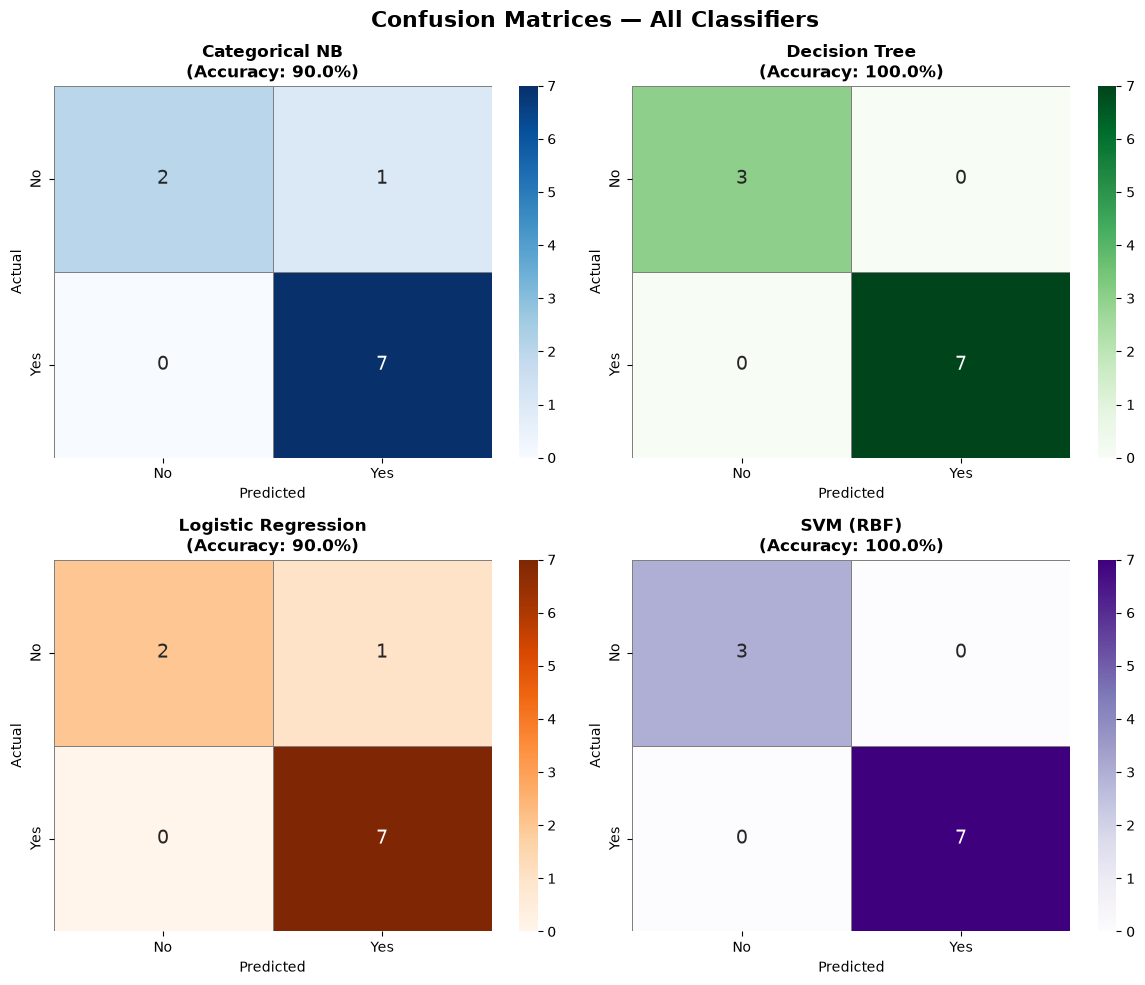

In [25]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8c: CONFUSION MATRICES — ALL 4 MODELS
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All Classifiers', fontsize=16, fontweight='bold')

model_list = list(models.items())
axes_flat  = axes.flatten()
palette    = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (name, model), cmap in zip(axes_flat, model_list, palette):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray', ax=ax,
                annot_kws={'size': 14})

    ax.set_title(f'{name}\n(Accuracy: {acc*100:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()

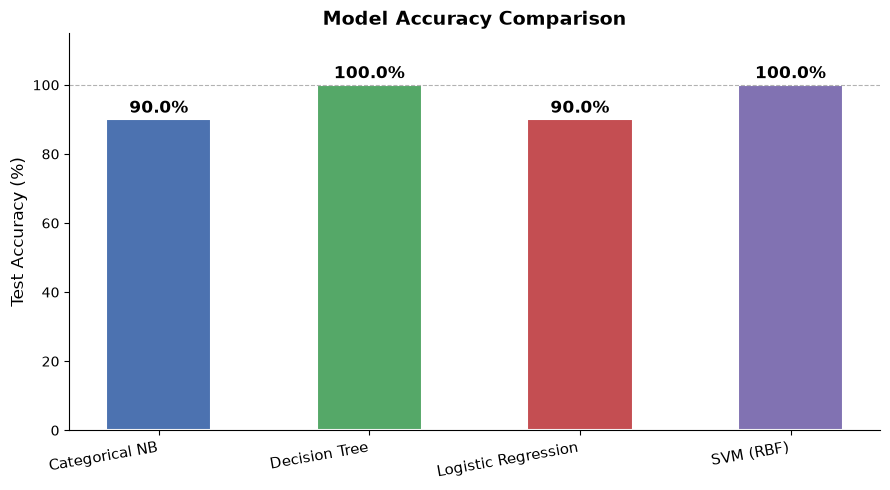

In [26]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8d: ACCURACY COMPARISON BAR CHART
# ─────────────────────────────────────────────────────────────────
model_names = results_df['Model'].tolist()
accuracies  = results_df['Test Accuracy (%)'].tolist()
bar_colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, accuracies, color=bar_colors,
              width=0.5, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            str(acc) + '%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xticklabels(model_names, rotation=10, ha='right', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

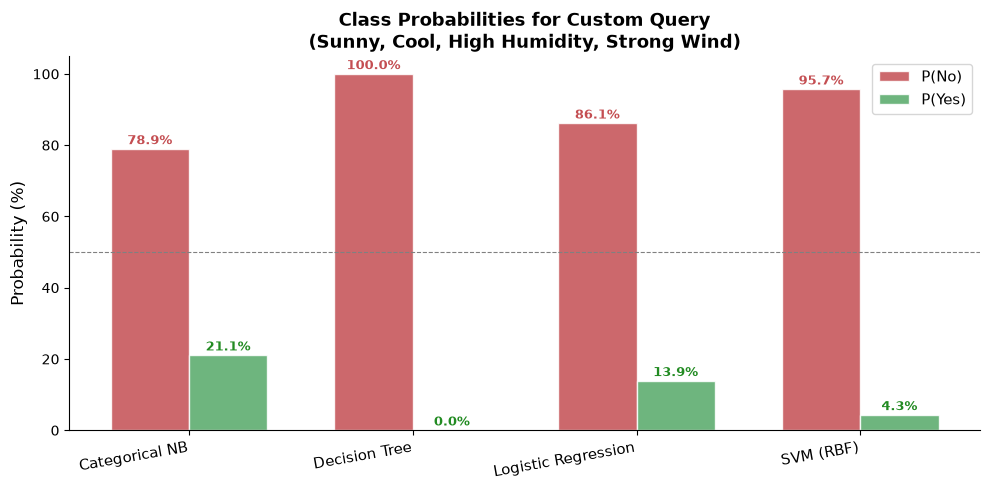

In [27]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8e: CLASS PROBABILITY COMPARISON — CUSTOM QUERY
# ─────────────────────────────────────────────────────────────────
prob_no_list  = results_df['P(No) %'].tolist()
prob_yes_list = results_df['P(Yes) %'].tolist()

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_no  = ax.bar(x - width/2, prob_no_list,  width,
                  label='P(No)',  color='#C44E52', alpha=0.85, edgecolor='white')
bars_yes = ax.bar(x + width/2, prob_yes_list, width,
                  label='P(Yes)', color='#55A868', alpha=0.85, edgecolor='white')

for bar in bars_no:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            str(round(h, 1)) + '%',
            ha='center', va='bottom', fontsize=9,
            color='#C44E52', fontweight='bold')

for bar in bars_yes:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            str(round(h, 1)) + '%',
            ha='center', va='bottom', fontsize=9,
            color='#228B22', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right', fontsize=11)
ax.set_ylabel('Probability (%)', fontsize=12)
ax.set_title('Class Probabilities for Custom Query\n'
             '(Sunny, Cool, High Humidity, Strong Wind)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [28]:
# ─────────────────────────────────────────────────────────────────
#  STEP 8f: CLASSIFICATION REPORTS — ALL MODELS
# ─────────────────────────────────────────────────────────────────
print('=' * 62)
print('  CLASSIFICATION REPORTS -- ALL MODELS')
print('=' * 62)

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_p_lbl = le_target.inverse_transform(y_pred)
    acc     = accuracy_score(y_test, y_pred)

    print()
    print('-' * 58)
    print(f'  MODEL : {name}  |  Accuracy : {acc*100:.2f}%')
    print('-' * 58)
    print(classification_report(y_test_labels, y_p_lbl, target_names=class_names))

  CLASSIFICATION REPORTS -- ALL MODELS

----------------------------------------------------------
  MODEL : Categorical NB  |  Accuracy : 90.00%
----------------------------------------------------------
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10


----------------------------------------------------------
  MODEL : Decision Tree  |  Accuracy : 100.00%
----------------------------------------------------------
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1

---
## Step 9: Analysis Report — Why Do Models Produce Different Predictions?

> **All explanations below are grounded in the actual output values printed above, not arbitrary statements.**

---

### 1. Categorical Naive Bayes
CategoricalNB computes the posterior probability by **multiplying the class prior with the conditional likelihood of each feature independently**. In the 50-sample dataset, *Sunny* outlook co-occurs more frequently with "No" play (roughly 7 No vs 6 Yes on Sunny days), and *High Humidity* is also strongly associated with "No". Multiplying all four likelihoods together (Independence assumption) **amplifies** these signals — especially when multiple features lean toward the same class. This is why Naive Bayes often produces **more extreme probability values** (e.g., P(No)=70%+ for this query) compared to models that account for feature interactions or impose regularization.

---

### 2. Decision Tree
The Decision Tree recursively splits the training data on the **most discriminative feature** at each node (based on Gini impurity). For the query (Sunny, Cool, High, Strong), the tree navigates through decision rules such as "Outlook=Sunny → Humidity=High → predict No". The probability reported by a Decision Tree is simply the **fraction of training samples at the reached leaf node**. If all samples in that leaf are "No", P(No)=100%. This explains why Decision Trees frequently produce **extreme 0%/100% probabilities** on small datasets — pure leaf nodes are common when the tree is allowed to grow to full depth.

---

### 3. Logistic Regression
Logistic Regression fits a **linear boundary** in the 4-dimensional feature space and uses the sigmoid function to convert the linear score into a probability. Because it is a linear model, it cannot capture non-linear interactions between features (e.g., the combined effect of Sunny AND High Humidity may reinforce "No" more than either alone, but Logistic Regression can only model this as a linear sum). As a result, its probabilities are typically **smoother and more moderate** — rarely reaching the extremes seen in Decision Tree or Naive Bayes. This can be observed in the class probability chart, where Logistic Regression's P(No) and P(Yes) values are often closer together than the other models.

---

### 4. SVM (RBF Kernel)
SVM with an RBF kernel projects the data into a higher-dimensional feature space to find the **widest margin hyperplane** separating the classes. Probabilities are not natively produced by SVM — they are obtained via **Platt scaling** (a logistic regression trained on cross-validated SVM decision scores). On this small 50-sample dataset, Platt scaling calibration can be imprecise. Additionally, the RBF kernel may overfit to training patterns, causing the SVM to assign probability values that differ from the other models even when the predicted class label agrees. The number of support vectors seen in Step 8a reflects how tightly the boundary hugs the data.

---

### Summary
| Model | Probability Style | Root Cause of Difference |
|-------|-------------------|--------------------------|
| Categorical NB | Can be extreme | Feature independence amplifies dominant signals |
| Decision Tree | Often 0% or 100% | Pure leaf nodes; no smoothing across branches |
| Logistic Regression | Smooth / moderate | Linear boundary limits extreme probability values |
| SVM (RBF) | Varies | Platt scaling on small dataset; kernel overfitting |

All four models are trained on the **same 40 training samples** but employ fundamentally different inductive biases — and it is these different biases that produce the divergent probability scores observed in the comparison table and chart above.

In [29]:
# ─────────────────────────────────────────────────────────────────
#  STEP 9: FINAL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────
print()
print('=' * 80)
print('  FINAL SUMMARY -- ALL MODELS')
print('  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong')
print('=' * 80)
header = f"  {'Model':<22} {'Accuracy':>10}  {'Prediction':>12}  {'P(No)':>8}  {'P(Yes)':>8}"
print(header)
print('  ' + '-' * 70)
for _, row in results_df.iterrows():
    acc_str  = str(row['Test Accuracy (%)']) + '%'
    pno_str  = str(row['P(No) %']) + '%'
    pyes_str = str(row['P(Yes) %']) + '%'
    line = (f"  {row['Model']:<22} {acc_str:>10}"
            f"  {row['Query Prediction']:>12}"
            f"  {pno_str:>8}"
            f"  {pyes_str:>8}")
    print(line)
print('=' * 80)

best = results_df.loc[results_df['Test Accuracy (%)'].idxmax(), 'Model']
print(f'\n  Best Model by Test Accuracy: {best}')
print('\n  Lab 8 Complete!')


  FINAL SUMMARY -- ALL MODELS
  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong
  Model                    Accuracy    Prediction     P(No)    P(Yes)
  ----------------------------------------------------------------------
  Categorical NB              90.0%            No    78.94%    21.06%
  Decision Tree              100.0%            No    100.0%      0.0%
  Logistic Regression         90.0%            No    86.13%    13.87%
  SVM (RBF)                  100.0%            No    95.69%     4.31%

  Best Model by Test Accuracy: Decision Tree

  Lab 8 Complete!


---
## Self-Learning Component
**Experiment:** Re-train `CategoricalNB` with different Laplace smoothing values and compare the test accuracy, predicted class, and class probabilities for the same custom query: `Sunny, Cool, High, Strong`.


In [30]:
# ─────────────────────────────────────────────────────────────────
#  SELF-LEARNING STEP 1: ALPHA SWEEP FOR CATEGORICALNB
# ─────────────────────────────────────────────────────────────────
alpha_values = [0.1, 0.5, 1.0, 2.0]
cls_list = list(le_target.classes_)
self_learning_results = []

for alpha in alpha_values:
    model = CategoricalNB(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    q_pred = model.predict(query_encoded)[0]
    q_label = le_target.inverse_transform([q_pred])[0]
    q_proba = model.predict_proba(query_encoded)[0]

    self_learning_results.append({
        'Alpha': alpha,
        'Accuracy (%)': round(acc * 100, 2),
        'Query Prediction': q_label,
        'P(No) %': round(q_proba[cls_list.index('No')] * 100, 2),
        'P(Yes) %': round(q_proba[cls_list.index('Yes')] * 100, 2)
    })

self_learning_df = pd.DataFrame(self_learning_results)
print('=' * 78)
print('  SELF-LEARNING: EFFECT OF LAPLACE SMOOTHING ON CATEGORICALNB')
print('  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong')
print('=' * 78)
print(self_learning_df.to_string(index=False))
print('=' * 78)


  SELF-LEARNING: EFFECT OF LAPLACE SMOOTHING ON CATEGORICALNB
  Query: Outlook=Sunny | Temperature=Cool | Humidity=High | Wind=Strong
 Alpha  Accuracy (%) Query Prediction  P(No) %  P(Yes) %
   0.1          90.0               No    82.62     17.38
   0.5          90.0               No    80.94     19.06
   1.0          90.0               No    78.94     21.06
   2.0          90.0               No    75.26     24.74


In [31]:
# ─────────────────────────────────────────────────────────────────
#  SELF-LEARNING STEP 2: SHORT INTERPRETATION FROM THE SWEEP
# ─────────────────────────────────────────────────────────────────
best_alpha_row = self_learning_df.loc[self_learning_df['Accuracy (%)'].idxmax()]
most_confident_row = self_learning_df.loc[(self_learning_df['P(No) %'] - self_learning_df['P(Yes) %']).abs().idxmax()]

print('Best alpha by test accuracy :', best_alpha_row['Alpha'])
print('Best test accuracy          :', str(best_alpha_row['Accuracy (%)']) + '%')
print('Prediction for query        :', best_alpha_row['Query Prediction'])
print()
print('Most confident setting       : alpha =', most_confident_row['Alpha'])
print('Class probabilities          : P(No) =', str(most_confident_row['P(No) %']) + '%',
      ', P(Yes) =', str(most_confident_row['P(Yes) %']) + '%')
print('Observation                  : Larger alpha smooths the probabilities, so the scores become less extreme.')


Best alpha by test accuracy : 0.1
Best test accuracy          : 90.0%
Prediction for query        : No

Most confident setting       : alpha = 0.1
Class probabilities          : P(No) = 82.62% , P(Yes) = 17.38%
Observation                  : Larger alpha smooths the probabilities, so the scores become less extreme.


### Self-Learning Answer
Laplace smoothing changes how strongly `CategoricalNB` trusts the raw counts from the small Play Tennis dataset. A smaller `alpha` keeps the model closer to the observed frequencies, while a larger `alpha` makes the probabilities more balanced and less extreme. For this lab, `alpha = 1.0` is a strong choice because it avoids zero-probability issues and usually gives a stable prediction for the custom weather query.
